In [1]:
import sys
sys.path.append('../')
import os.path as osp

import torch
from torch.utils.data import DataLoader
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import utils

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

/home/mdrnevich/test/QuasiDRE/SMEFT/../utils/__init__.py:4: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  from . import plotting


cuda:0


# Now create a combined model and optimize the coefficients

In [2]:
SAVE_DIR = "./models"

In [3]:
submodel_names = np.array(["Pos", "Neg", "Pos", "Neg"])
combos = [np.array((0,2)), #++
          np.array((0,3))] #+-

NUM_MODELS = 2

In [4]:
batch_sizes = [int(2**6), int(2**6)]
subdensity_model_paths = [osp.join(SAVE_DIR, "classifier_subdensity_{}_batch{}.zip".format(''.join(submodel_names[combos[i]]), batch_sizes[i])) for i in range(NUM_MODELS)]

In [5]:
FINE_TUNE = True

t0 = 25619
t1 = 58
print(t0, t1, -(t0/t1)**2, -t0/t1)

mix_model = utils.models.SingleMixtureClassifier(subdensity_model_paths, which_mixture=1, t0=t0, t1=t1, fine_tune=FINE_TUNE).to(DEVICE)

25619 58 -195104.9824613555 -441.7068965517241


In [6]:
source_file = "./data/SMEFT_SM_combined_tuple"
target_file = "./data/SMEFT_EFT_combined_tuple"

source_positive_file = source_file + "_positives"
source_negative_file = source_file + "_negatives"
target_positive_file = target_file + "_positives"
target_negative_file = target_file + "_negatives"

files = [source_positive_file, source_negative_file, target_positive_file, target_negative_file]

sum_weights = []
for f in files:
    sum_weights.append(np.load(f + "_train.npy")[:,-1].sum())

sum_weights = np.array(sum_weights)
sum_weights

array([12994.63 ,     0.   , 16123.247, -3401.849], dtype=float32)

In [7]:
coefficient_init = [sum_weights[0] / sum_weights[:2].sum(), sum_weights[2] / sum_weights[2:].sum()]
coefficient_init

[np.float32(1.0), np.float32(1.2674116)]

In [8]:
mix_model.initialize(coefficient_init)
list(mix_model.parameters())

[Parameter containing:
 tensor(1., requires_grad=True),
 Parameter containing:
 tensor(1.2674, requires_grad=True),
 Parameter containing:
 tensor([[ 0.0353, -0.0427, -0.0358,  ..., -0.1024, -0.1737,  0.1159],
         [ 0.1301,  0.1362, -0.1057,  ..., -0.1218,  0.0944,  0.3300],
         [-0.0271, -0.0368,  0.0529,  ..., -0.0144,  0.2923,  0.1640],
         ...,
         [ 0.0521,  0.0994,  0.0285,  ...,  0.3119,  0.1464, -0.0622],
         [ 0.0619,  0.2458, -0.2035,  ...,  0.2749, -0.0610,  0.1659],
         [ 0.0019, -0.1044,  0.0085,  ...,  0.4439,  0.2333, -0.0664]],
        device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([-0.1680, -0.3290, -0.4603, -0.1793, -0.6143, -0.3171, -0.2135,  0.1254,
          0.3707, -0.1573, -0.2557,  0.1199,  0.0222, -0.1553, -0.5097, -0.1074,
          0.0408,  0.2572, -0.1940, -0.4951, -0.2427, -0.5611,  0.0041, -0.0669,
         -0.4043,  0.1101,  0.0432, -0.3689, -0.0469, -0.3448, -0.0880, -0.2642,
         -0.4167, -0.5000, 

In [9]:
training_settings_mix = {}    

train_base_dataset = utils.preprocessing.Dataset(source_file + "_train.npy", 0)
valid_base_dataset = utils.preprocessing.Dataset(source_file + "_val.npy", 0)

train_target_dataset = utils.preprocessing.Dataset(target_file + "_train.npy", 1)
valid_target_dataset = utils.preprocessing.Dataset(target_file + "_val.npy", 1)

training_settings_mix.update({
    "source_file": source_file,
    "target_file": target_file,
    "t0": t0,
    "t1": t1
})

In [10]:
train_base_dataset.process(normalize_weights=True)
valid_base_dataset.process(normalize_weights=True)

train_target_dataset.process(normalize_weights=True)
valid_target_dataset.process(normalize_weights=True)

tensor(0.0164)

In [11]:
train_generator_data = utils.preprocessing.CombinedDataset(train_base_dataset, train_target_dataset)
valid_generator_data = utils.preprocessing.CombinedDataset(valid_base_dataset, valid_target_dataset)

In [12]:
X_scaler, train_weight_norm = utils.preprocessing.get_scaling(train_generator_data)
_, valid_weight_norm = utils.preprocessing.get_scaling(valid_generator_data)
print(train_weight_norm, valid_weight_norm, train_weight_norm/valid_weight_norm)

100%|██████████| 350/350 [00:01<00:00, 251.94it/s]

tensor(1.0000) tensor(1.0000) tensor(1.0000)


In [13]:
random_seed = 0

batch_size = int(2**6)
torch.manual_seed(random_seed)

train_loader = DataLoader(train_generator_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_generator_data, batch_size=batch_size, shuffle=False)

## Save the plain SMM model

In [14]:
SAVE_SMM = True

if SAVE_SMM is True:
    SMM_model = utils.models.SingleMixtureClassifier(subdensity_model_paths, which_mixture=1, t0=t0, t1=t1, fine_tune=False).to(DEVICE)
    SMM_model.initialize(coefficient_init)
    model_path = osp.join(SAVE_DIR, "classifier_SMM")
    model_metadata = utils.train.get_model_metadata(training_settings_mix, SMM_model, X_scaler, train_weight_norm)
    utils.train.save_model_data(SMM_model, model_metadata, name=model_path, save_onnx=False, device=DEVICE)

## Now train the others

In [17]:
learning_rate = 1e-5
optimizer = torch.optim.Adam(mix_model.parameters(), lr=learning_rate)

if FINE_TUNE is False:
    model_name = "classifier_SMMc_batch{}".format(batch_size)
else:
    model_name = "classifier_SMMr_batch{}".format(batch_size)

In [18]:
n_epochs = 300
stale_epochs = 0
best_valid_loss = 99999
patience = 10
max_num_batches = int(int(1e4) / batch_size)
t = tqdm(range(0, n_epochs))

training_losses = [utils.train.test(
        mix_model,
        train_loader,
        weight_norm=train_weight_norm,
        loss='pare',
        SMM=True,
        t0=t0,
        t1=t1,
        device=DEVICE,
        max_num_batches=max_num_batches,
        progress_bar=False,
        leave=False
    )[0],]
validation_losses = [utils.train.test(
        mix_model,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='pare',
        SMM=True,
        t0=t0,
        t1=t1,
        device=DEVICE,
        progress_bar=False,
        leave=False
    )[0],]

for epoch in t:
    loss = utils.train.train(
        mix_model,
        optimizer,
        train_loader,
        weight_norm=train_weight_norm,
        max_num_batches=max_num_batches,
        loss='pare',
        SMM=True,
        t0=t0,
        t1=t1,
        device=DEVICE,
        progress_bar=False,
        leave=bool(epoch == n_epochs - 1),
    )
    #loss -= optimal_train_loss
    training_losses.append(loss[0])

    valid_loss = utils.train.test(
        mix_model,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='pare',
        SMM=True,
        t0=t0,
        t1=t1,
        device=DEVICE,
        progress_bar=False,
        leave=bool(epoch == n_epochs - 1),
    )
    #valid_loss -= optimal_valid_loss
    validation_losses.append(valid_loss[0])
    print("Epoch: {:02d}, Training Loss:   {:.4f}".format(epoch, loss[1]))
    print("           Validation Loss: {:.4f}".format(valid_loss[1]))

    if valid_loss[1] < best_valid_loss and np.abs((loss[1] - valid_loss[1]) / loss[1]) < 0.2: # Don't allow large fluctuations
        best_valid_loss = valid_loss[1]
        print("New best model with parameters:", mix_model.coefficients)
        training_settings_mix.update({
            "n_epochs": epoch+1,
            "training_losses": training_losses,
            "validation_losses": validation_losses
        })
        model_metadata = utils.train.get_model_metadata(training_settings_mix, mix_model, X_scaler, train_weight_norm)
        utils.train.save_model_data(mix_model, model_metadata, savedir=SAVE_DIR, name=model_name, save_onnx=False, device=DEVICE)
        print("New best model saved to: {}.zip".format(osp.join(SAVE_DIR, model_name)))
        stale_epochs = 0
    else:
        print("Stale epoch")
        stale_epochs += 1
    if stale_epochs >= patience:
        print("Early stopping after %i stale epochs" % patience)
        break

  0%|          | 0/300 [00:00<?, ?it/s]

Epoch: 00, Training Loss:   0.5080
           Validation Loss: 0.4977
New best model with parameters: (1.0, 1.2678788900375366)
New best model saved to: ./models/classifier_SMMr_batch64.zip
Epoch: 01, Training Loss:   0.4779
           Validation Loss: 0.4977
Stale epoch
Epoch: 02, Training Loss:   0.4880
           Validation Loss: 0.4977
New best model with parameters: (1.0, 1.2675647735595703)
New best model saved to: ./models/classifier_SMMr_batch64.zip
Epoch: 03, Training Loss:   0.4977
           Validation Loss: 0.4977
New best model with parameters: (1.0, 1.2674611806869507)
New best model saved to: ./models/classifier_SMMr_batch64.zip
Epoch: 04, Training Loss:   0.4856
           Validation Loss: 0.4977
New best model with parameters: (1.0, 1.2673096656799316)
New best model saved to: ./models/classifier_SMMr_batch64.zip
Epoch: 05, Training Loss:   0.4964
           Validation Loss: 0.4977
New best model with parameters: (1.0, 1.2670097351074219)
New best model saved to: ./mod

## Look at the loss curves

Text(0, 0.5, 'PARE Loss')

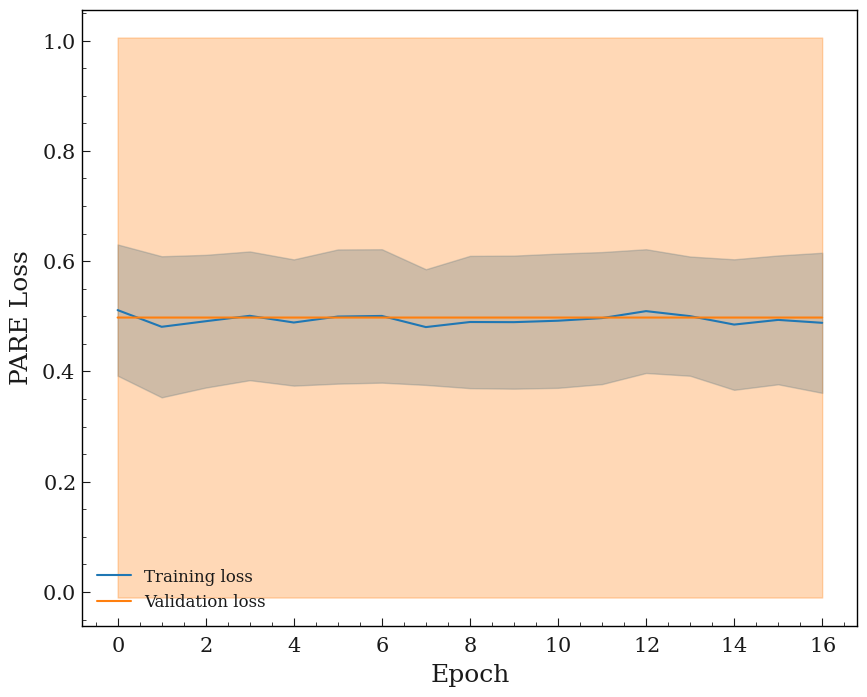

In [20]:
fig,ax = plt.subplots()
fig.set_size_inches(10, 8)

starting_epoch = 1
training_loss_per_epoch = np.array(training_losses[starting_epoch:]).mean(axis=1)
training_std_per_epoch = np.array(training_losses[starting_epoch:]).std(axis=1)

validation_loss_per_epoch = np.array(validation_losses[starting_epoch:]).mean(axis=1)
validation_std_per_epoch = np.array(validation_losses[starting_epoch:]).std(axis=1)

training_lower_bar = training_loss_per_epoch - training_std_per_epoch
training_upper_bar = training_loss_per_epoch + training_std_per_epoch

validation_lower_bar = validation_loss_per_epoch - validation_std_per_epoch
validation_upper_bar = validation_loss_per_epoch + validation_std_per_epoch


t1 = np.arange(len(training_loss_per_epoch))
t2 = np.arange(len(validation_loss_per_epoch))
ax.plot(t1, training_loss_per_epoch, '-', label="Training loss", c='tab:blue')
ax.fill_between(t1, training_lower_bar, training_upper_bar, color='tab:blue', alpha=0.30)

ax.plot(t2, validation_loss_per_epoch, '-', label="Validation loss", c='tab:orange')
ax.fill_between(t2, validation_lower_bar, validation_upper_bar, color='tab:orange', alpha=0.30)

#ax.set_xscale('log')
ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("PARE Loss")